## Machine Learning - Linear Regression

In [2]:
import pandas as pd
import numpy as np

In [3]:
#Sales price prediction using Ames Housing Dataset
df=pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep='\t')
df.head()
df.info()
df.sample(2)

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1389,1390,905201020,20,RL,94.0,9239,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,144900
182,183,902207140,30,RM,60.0,8520,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,105900


In [4]:
df=df[["Overall Qual", "Overall Cond", "Total Bsmt SF", "Gr Liv Area", "Central Air", "SalePrice"]]
df.dropna(axis=0,inplace=True) #널이 있는 row 떨구기, inplace = 참으로 하면 그자리에서 수정
df.isna().sum()


Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Gr Liv Area      0
Central Air      0
SalePrice        0
dtype: int64

In [5]:
print(df["Central Air"].value_counts())
df["Central Air"] = df["Central Air"].map({"Y":1, "N":0})
print(df["Central Air"].value_counts())

Central Air
Y    2733
N     196
Name: count, dtype: int64
Central Air
1    2733
0     196
Name: count, dtype: int64


### EDA (Exploratory Data Analysis)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns 

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

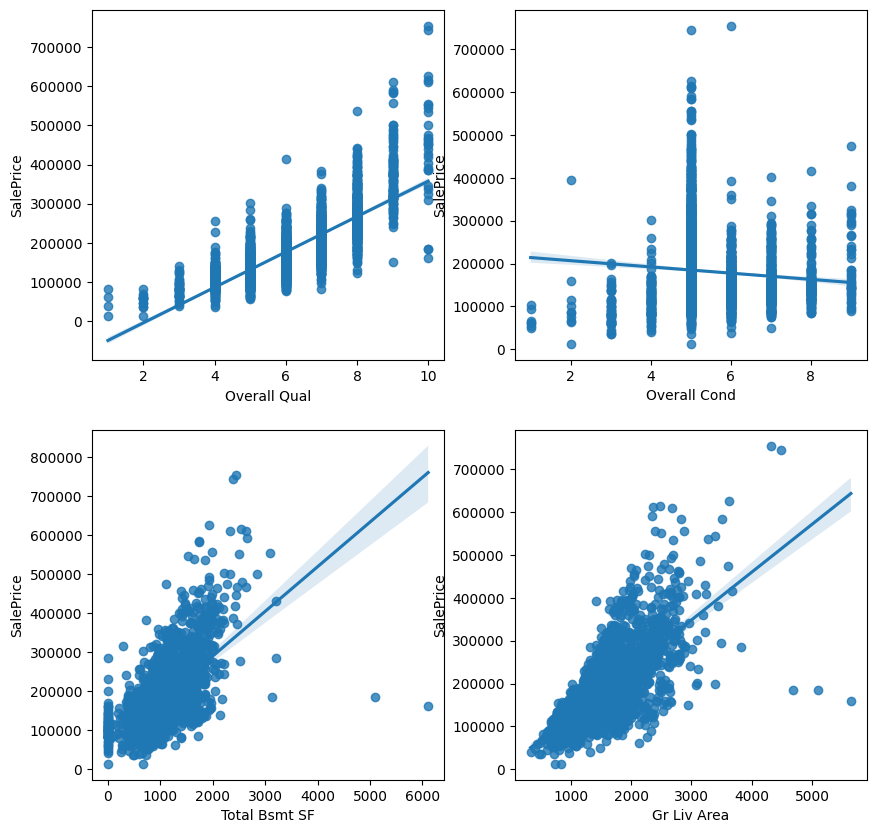

In [7]:
fig, ax = plt.subplots(2,2, figsize =(10,10))
sns.regplot(data = df, x = 'Overall Qual', y= 'SalePrice', ax = ax[0,0]) #regression plot
sns.regplot(data = df, x = 'Overall Cond', y= 'SalePrice',ax = ax[0,1])
sns.regplot(data = df, x = 'Total Bsmt SF', y= 'SalePrice',ax = ax[1,0])
sns.regplot(data = df, x = 'Gr Liv Area', y= 'SalePrice',ax = ax[1,1]) 

<Axes: xlabel='Central Air', ylabel='SalePrice'>

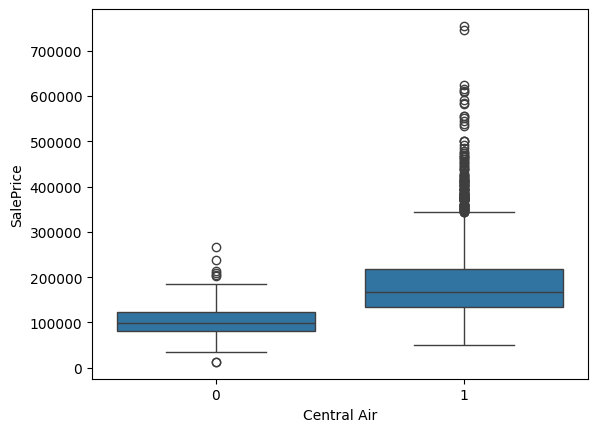

In [ ]:
sns.boxplot(data=df, x='Central Air', y='SalePrice') #in ML preprocessing/ choosing delornot outlier 